In [3]:
# =========================
# Core
# =========================
import math
import yaml

import numpy as np
import pandas as pd

# =========================
# Plotting
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# Machine learning
# =========================
import xgboost as xgb
import shap
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval

from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except ImportError:
    HAS_LOWESS = False

from sklearn.preprocessing import MinMaxScaler


/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def _trend_line(x, y, frac=0.4, n_bins=20):
    """Return smoothed (x_sorted, y_smooth) via LOWESS, or a binned-mean
    fallback if statsmodels isn't available."""
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]

    if HAS_LOWESS:
        smoothed = lowess(y_sorted, x_sorted, frac=frac, return_sorted=True)
        return smoothed[:, 0], smoothed[:, 1]

    # Fallback: binned mean
    bins = np.linspace(x_sorted.min(), x_sorted.max(), n_bins + 1)
    bin_idx = np.digitize(x_sorted, bins) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    x_binned, y_binned = [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() > 0:
            x_binned.append(x_sorted[mask].mean())
            y_binned.append(y_sorted[mask].mean())
    return np.array(x_binned), np.array(y_binned)

def plot_shap(
    df,
    features,
    color="#56B4E9",
    line_color="#D55E00",
    y_axis_limits=(-0.03, 0.03),
    shap_prefix="shap_",
    n_cols=5,
    name=None,
    title=None,
    lowess_frac=0.4,
):
    """
    Plot SHAP dependence for each feature, with a LOWESS trend line,
    from a wide-format dataframe where each feature has a matching
    shap_<feature> column.
    """
    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.6 * n_cols, 4.2 * n_rows),
        squeeze=False
    )
    axes = axes.reshape(-1)

    for ax, var in zip(axes, features):
        shap_col = f"{shap_prefix}{var}"

        if var not in df.columns or shap_col not in df.columns:
            print(f"Skipping {var}: column(s) not found ({var}, {shap_col})")
            ax.set_visible(False)
            continue

        feature_values = df[var].values.astype(float)
        shap_feature = df[shap_col].values.astype(float)

        valid = ~(np.isnan(feature_values) | np.isnan(shap_feature))
        feature_values, shap_feature = feature_values[valid], shap_feature[valid]

        if len(feature_values) < 5 or np.all(feature_values == feature_values[0]):
            ax.set_visible(False)
            continue

        # Points
        ax.scatter(
            feature_values,
            shap_feature,
            alpha=0.08,
            s=10,
            color=color,
            linewidth=0,
            zorder=1,
            rasterized=True,  # keeps vector PDFs from bloating with dense scatter
        )

        # LOWESS trend line
        x_smooth, y_smooth = _trend_line(feature_values, shap_feature, frac=lowess_frac)
        ax.plot(
            x_smooth,
            y_smooth,
            color=line_color,
            linewidth=2.2,
            zorder=4,
        )

        if y_axis_limits:
            ax.set_ylim(*y_axis_limits)
        ax.axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)

        # Clean spines + gridlines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(axis='y', color='#eeeeee', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        ax.set_xlabel(var, fontweight='medium')
        ax.set_ylabel("SHAP value")
        ax.set_title(var, fontweight='bold', fontsize=11, pad=8)

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle(title or "Overall SHAP Dependence Plots", y=1.06, fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.88)

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig

def plot_shap_by_continuous(
    df,
    features,
    color_var,               # name of the continuous column to color points by
    cmap="viridis",
    shap_prefix="shap_",
    n_cols=5,
    name=None,
    title=None,
    lowess_frac=0.4,
    trend_color="#D55E00",   # single global trend line color (contrasts with most cmaps)
    color_var_label=None,    # optional display label for the colorbar
    vmin=None,
    vmax=None,
):
    """
    Plot SHAP dependence with points colored by a continuous variable
    (shared colormap + colorbar across all panels), and a single pooled
    trend line per feature (fit across all data, ignoring color_var).
    """
    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.6 * n_cols, 4.2 * n_rows),
        squeeze=False
    )
    axes = axes.reshape(-1)

    # Shared color scale across all panels, so colors are comparable subplot-to-subplot
    if color_var not in df.columns:
        raise ValueError(f"color_var '{color_var}' not found in df.columns")
    c_all = df[color_var].values.astype(float)
    c_valid = c_all[~np.isnan(c_all)]
    vmin = c_valid.min() if vmin is None else vmin
    vmax = c_valid.max() if vmax is None else vmax
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    last_scatter = None

    for ax, var in zip(axes, features):
        shap_col = f"{shap_prefix}{var}"

        if var not in df.columns or shap_col not in df.columns:
            print(f"Skipping {var}: column(s) not found ({var}, {shap_col})")
            ax.set_visible(False)
            continue

        feature_values = df[var].values.astype(float)
        shap_feature = df[shap_col].values.astype(float)
        c_values = df[color_var].values.astype(float)

        valid = ~(np.isnan(feature_values) | np.isnan(shap_feature) | np.isnan(c_values))
        feature_values, shap_feature, c_values = (
            feature_values[valid], shap_feature[valid], c_values[valid]
        )

        if len(feature_values) < 5 or np.all(feature_values == feature_values[0]):
            ax.set_visible(False)
            continue

        # Points colored by the continuous variable
        last_scatter = ax.scatter(
            feature_values,
            shap_feature,
            c=c_values,
            cmap=cmap,
            norm=norm,
            alpha=0.08,
            s=10,
            linewidth=0,
            zorder=1,
            rasterized=True,  # keeps vector PDFs from bloating with dense scatter
        )

        # Single global trend line (pooled, ignores color_var)
        x_smooth, y_smooth = _trend_line(feature_values, shap_feature, frac=lowess_frac)
        ax.plot(
            x_smooth, y_smooth,
            color=trend_color,
            linewidth=2.4,
            zorder=4,
            solid_capstyle='round',
        )

        ax.set_ylim(-0.03, 0.03)
        ax.axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(axis='y', color='#eeeeee', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        ax.set_xlabel(var, fontweight='medium')
        ax.set_ylabel("SHAP value")
        ax.set_title(var, fontweight='bold', fontsize=11, pad=8)

    for ax in axes[n_plots:]:
        ax.set_visible(False)
    # Shared colorbar for the continuous variable
    if last_scatter is not None:
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(
            sm, ax=axes[:n_plots].tolist(),
            orientation='vertical',
            fraction=0.02, pad=0.02,
            location='right'
        )
        cbar.set_label(color_var_label or color_var, fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    # Trend-line legend entry (kept separate from the colorbar)
    legend_elements = [
        Line2D([0], [0], color=trend_color, lw=2.4, label="Overall trend (LOWESS)")
    ]
    fig.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        frameon=False,
        fontsize=10,
    )
    fig.suptitle(title or "Overall SHAP Dependence Plots", y=1.1, fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.85)

    return fig

def plot_shap_by_group(
    df,
    features,
    group_color_map,          # dict: {biome_name: color}
    group_col="biome",
    shap_prefix="shap_",
    n_cols=5,
    name=None,
    title=None,
    lowess_frac=0.4,
    trend_color="#333333",   # single global trend line color
):
    """
    Plot SHAP dependence with points colored per biome, but a single
    pooled trend line per feature (fit across all groups combined).
    Colors come from group_color_map.
    """
    groups = [g for g in group_color_map.keys() if g in df[group_col].unique()]

    missing = set(df[group_col].dropna().unique()) - set(group_color_map.keys())
    if missing:
        print(f"Warning: these groups have no color mapping and will be skipped: {missing}")

    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.6 * n_cols, 4.2 * n_rows),
        squeeze=False
    )
    axes = axes.reshape(-1)

    for ax, var in zip(axes, features):
        shap_col = f"{shap_prefix}{var}"

        if var not in df.columns or shap_col not in df.columns:
            print(f"Skipping {var}: column(s) not found ({var}, {shap_col})")
            ax.set_visible(False)
            continue

        # --- Plot points per group first ---
        for g in groups:
            sub = df[df[group_col] == g]
            feature_values = sub[var].values.astype(float)
            shap_feature = sub[shap_col].values.astype(float)

            if len(feature_values) == 0 or np.all(feature_values == feature_values[0]):
                continue

            color = group_color_map[g]

            ax.scatter(
                feature_values,
                shap_feature,
                alpha=0.08,
                s=10,
                color=color,
                linewidth=0,
                zorder=1,
                rasterized=True,  # keeps vector PDFs from bloating with dense scatter
            )

        # --- Single global trend line, pooled across all groups ---
        all_feature_values = df[var].values.astype(float)
        all_shap_feature = df[shap_col].values.astype(float)
        valid = ~(np.isnan(all_feature_values) | np.isnan(all_shap_feature))

        if valid.sum() >= 5:
            x_smooth, y_smooth = _trend_line(
                all_feature_values[valid], all_shap_feature[valid], frac=lowess_frac
            )
            ax.plot(
                x_smooth, y_smooth,
                color=trend_color,
                linewidth=2.4,
                zorder=4,
                solid_capstyle='round',
            )

        ax.set_ylim(-0.03, 0.03)
        ax.axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)

        # Clean spines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(axis='y', color='#eeeeee', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        ax.set_xlabel(var, fontweight='medium')
        ax.set_ylabel("SHAP value")
        ax.set_title(var, fontweight='bold', fontsize=11, pad=8)

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Legend: group colors + the trend line
    legend_elements = [
        Line2D([0], [0], color=group_color_map[g], lw=2.5, marker='o',
               linestyle='None', markersize=6, label=g)
        for g in groups
    ]
    legend_elements.append(
        Line2D([0], [0], color=trend_color, lw=2.4, label="Overall trend (LOWESS)")
    )
    fig.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.0),
        ncol=min(len(legend_elements), 6),
        frameon=False,
        fontsize=10,
    )

    fig.suptitle(title or "Overall SHAP Dependence Plots", y=1.06, fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.88)

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig

In [ ]:

def plot_shap_with_line_stats_v4(
    shap_values,
    X,
    features,
    biome=None,
    n_cols=3,
    name=None,
):
    """
    Plot SHAP dependence with a linear trend line and hexbin density.
    Each feature is plotted in its own subplot.
    """

    # vmin = X["Annual"].quantile(0.02)
    # vmax = X["WSCI"].quantile(0.9)

    colors = {
        "line": "slategrey",
    }

    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)
    fig.subplots_adjust(hspace=0.45, wspace=0.35)

    for ax, var in zip(axes, features):

        feature_idx = list(X.columns).index(var)

        feature_values = X[var].values.astype(float)
        shap_feature = shap_values[:, feature_idx].astype(float)

        # Skip empty variables
        if np.all(feature_values == 0):
            ax.set_visible(False)
            continue

        # -------------------------------
        # Fit straight line (linear regression)
        # -------------------------------
        slope, intercept = np.polyfit(feature_values, shap_feature, 1)
        y_pred = slope * feature_values + intercept

        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - shap_feature.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        # -------------------------------
        # Plot limits
        # -------------------------------
        x_min = feature_values.min()
        x_max = feature_values.max()

        x_smooth = np.linspace(x_min, x_max, 300)
        y_smooth = slope * x_smooth + intercept

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.03, 0.03)

        # sc = ax.scatter(
        #     feature_values,
        #     shap_feature,
        #     alpha=0.1,
        #     vmin=vmin,
        #     vmax=vmax,
        #     s=5,
        #     cmap='PRGn',
        #     c=X['WSCI'],
        #     linewidth=0.3,
        #     zorder=1,
        # )
        sc = ax.scatter(
            feature_values,
            shap_feature,
            alpha=0.03,
            s=3,
            color='seagreen',
            linewidth=0.3,
            zorder=1,
        )
        # -------------------------------
        # Line
        # -------------------------------
        ax.plot(
            x_smooth,
            y_smooth,
            color=colors["line"],
            linewidth=2.5,
            zorder=5,
            label=f"Linear fit (R² = {r2:.2f}, slope = {slope:.4f})",
        )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.3,
        )

        ax.set_xlabel(var)
        ax.set_ylabel("SHAP value")
        ax.set_title(var)
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    title = (
        f"SHAP Dependence — {biome}"
        if biome is not None
        else "SHAP Dependence"
    )

    # norm = Normalize(
    #     vmin=X["WSCI"].min(),
    #     vmax=X["WSCI"].max()
    # )

    # sm = ScalarMappable(
    #     cmap="PRGn",
    #     norm=norm
    # )

    # sm.set_array([])

    # cbar = fig.colorbar(
    #     sm,
    #     ax=axes,
    #     fraction=0.03,
    #     pad=0.08,
    # )

    # cbar.set_label("WSCI")

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig


def plot_shap_with_polynomial_stats_v3(shap_values, X, features, biome=None, degree=2, name=None):
    """
    Plot SHAP dependence with polynomial trend and statistics.
    Single feature list, one plot per feature, no overlapping axes.
    """

    # colors = {
    #     'scatter':"#999CC2",
    #     'line':    "#3E47C6",
    # }
    # colors = {
    #     'scatter': "#F8C1F5",
    #     'line':    "#FE4CF5",
    # }
    colors = {
        'scatter': "lavender",
        'line':    "slategray",
    }
    n_plots = len(features)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    n_samples = min(shap_values.shape[0], 2000)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = np.array(axes).flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)

    for i, (ax, var) in enumerate(zip(axes_flat, features)):

        feature_values = X[var].values.astype(np.float64)
        feature_idx = list(X.columns).index(var)
        shap_feature = shap_values[:, feature_idx].astype(np.float64)

        # Skip if all zeros
        if np.all(feature_values == 0):
            ax.set_visible(False)
            continue

        # Sample
        indices = np.random.choice(len(feature_values), n_samples, replace=False)
        fv_sample = feature_values[indices]
        sv_sample = shap_feature[indices]

        # Polynomial fit on full data
        coeffs = np.polyfit(feature_values, shap_feature, degree)
        poly_func = np.poly1d(coeffs)

        # R²
        y_pred = poly_func(feature_values)
        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        # Scatter
        ax.scatter(fv_sample, sv_sample,
                   alpha=0.9, s=2, c=colors['scatter'],
                   edgecolor='darkgray',
                   linewidth=0.3, zorder=1)

        # Trend line
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 200)
        y_smooth = poly_func(x_smooth)
        ax.plot(x_smooth, y_smooth,
                c=colors['line'], linewidth=2,
                zorder=10)

        y_min = min(np.min(y_smooth), np.min(y_smooth))
        y_max = max(np.max(y_smooth), np.max(y_smooth))

        padding = 0.3 * (y_max - y_min)

        ax.set_ylim(y_min - padding, y_max + padding)
        # Reference line
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('SHAP value', fontsize=10)
        ax.set_title(f'{var}', fontsize=11, pad=8)
        ax.legend(fontsize=8, loc='best')

    # Hide unused axes
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    title = f'SHAP Dependence — {biome}' if biome else 'SHAP Dependence'
    fig.suptitle(title, fontsize=13, y=1.02)

    if name:
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap(
    df,
    features,
    color="#56B4E9",
    line_color="#D55E00",
    y_axis_limits=(-0.03, 0.03),
    shap_prefix="shap_",
    n_cols=5,
    name=None,
    title=None,
    lowess_frac=0.4,
):
    """
    Plot SHAP dependence for each feature, with a LOWESS trend line,
    from a wide-format dataframe where each feature has a matching
    shap_<feature> column.
    """
    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.6 * n_cols, 4.2 * n_rows),
        squeeze=False
    )
    axes = axes.reshape(-1)

    for ax, var in zip(axes, features):
        shap_col = f"{shap_prefix}{var}"

        if var not in df.columns or shap_col not in df.columns:
            print(f"Skipping {var}: column(s) not found ({var}, {shap_col})")
            ax.set_visible(False)
            continue

        feature_values = df[var].values.astype(float)
        shap_feature = df[shap_col].values.astype(float)

        valid = ~(np.isnan(feature_values) | np.isnan(shap_feature))
        feature_values, shap_feature = feature_values[valid], shap_feature[valid]

        if len(feature_values) < 5 or np.all(feature_values == feature_values[0]):
            ax.set_visible(False)
            continue

        # Points
        ax.scatter(
            feature_values,
            shap_feature,
            alpha=0.08,
            s=10,
            color=color,
            linewidth=0,
            zorder=1,
            rasterized=True,  # keeps vector PDFs from bloating with dense scatter
        )

        # LOWESS trend line
        x_smooth, y_smooth = _trend_line(feature_values, shap_feature, frac=lowess_frac)
        ax.plot(
            x_smooth,
            y_smooth,
            color=line_color,
            linewidth=2.2,
            zorder=4,
        )

        if y_axis_limits:
            ax.set_ylim(*y_axis_limits)
        ax.axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)

        # Clean spines + gridlines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(axis='y', color='#eeeeee', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        ax.set_xlabel(var, fontweight='medium')
        ax.set_ylabel("SHAP value")
        ax.set_title(var, fontweight='bold', fontsize=11, pad=8)

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle(title or "Overall SHAP Dependence Plots", y=1.06, fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.88)

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig

def plot_shap_by_continuous(
    df,
    features,
    color_var,               # name of the continuous column to color points by
    cmap="viridis",
    shap_prefix="shap_",
    n_cols=5,
    name=None,
    title=None,
    lowess_frac=0.4,
    trend_color="#D55E00",   # single global trend line color (contrasts with most cmaps)
    color_var_label=None,    # optional display label for the colorbar
    vmin=None,
    vmax=None,
):
    """
    Plot SHAP dependence with points colored by a continuous variable
    (shared colormap + colorbar across all panels), and a single pooled
    trend line per feature (fit across all data, ignoring color_var).
    """
    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.6 * n_cols, 4.2 * n_rows),
        squeeze=False
    )
    axes = axes.reshape(-1)

    # Shared color scale across all panels, so colors are comparable subplot-to-subplot
    if color_var not in df.columns:
        raise ValueError(f"color_var '{color_var}' not found in df.columns")
    c_all = df[color_var].values.astype(float)
    c_valid = c_all[~np.isnan(c_all)]
    vmin = c_valid.min() if vmin is None else vmin
    vmax = c_valid.max() if vmax is None else vmax
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    last_scatter = None

    for ax, var in zip(axes, features):
        shap_col = f"{shap_prefix}{var}"

        if var not in df.columns or shap_col not in df.columns:
            print(f"Skipping {var}: column(s) not found ({var}, {shap_col})")
            ax.set_visible(False)
            continue

        feature_values = df[var].values.astype(float)
        shap_feature = df[shap_col].values.astype(float)
        c_values = df[color_var].values.astype(float)

        valid = ~(np.isnan(feature_values) | np.isnan(shap_feature) | np.isnan(c_values))
        feature_values, shap_feature, c_values = (
            feature_values[valid], shap_feature[valid], c_values[valid]
        )

        if len(feature_values) < 5 or np.all(feature_values == feature_values[0]):
            ax.set_visible(False)
            continue

        # Points colored by the continuous variable
        last_scatter = ax.scatter(
            feature_values,
            shap_feature,
            c=c_values,
            cmap=cmap,
            norm=norm,
            alpha=0.08,
            s=7,
            linewidth=0,
            zorder=1,
            rasterized=True,  # keeps vector PDFs from bloating with dense scatter
        )

        # Single global trend line (pooled, ignores color_var)
        x_smooth, y_smooth = _trend_line(feature_values, shap_feature, frac=lowess_frac)
        ax.plot(
            x_smooth, y_smooth,
            color=trend_color,
            linewidth=2.4,
            zorder=4,
            solid_capstyle='round',
        )

        ax.set_ylim(-0.03, 0.03)
        ax.axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(axis='y', color='#eeeeee', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        ax.set_xlabel(var, fontweight='medium')
        ax.set_ylabel("SHAP value")
        ax.set_title(var, fontweight='bold', fontsize=11, pad=8)

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Shared colorbar for the continuous variable
    if last_scatter is not None:
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(
            sm, ax=axes[:n_plots].tolist(),
            orientation='horizontal',
            fraction=0.02, pad=0.06,
            location='top'
        )
        cbar.set_label(color_var_label or color_var, fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    # Trend-line legend entry (kept separate from the colorbar)
    legend_elements = [
        Line2D([0], [0], color=trend_color, lw=2.4, label="Overall trend (LOWESS)")
    ]
    fig.legend(
        handles=legend_elements,
        loc='upper right',
        bbox_to_anchor=(0.99, 1.0),
        frameon=False,
        fontsize=10,
    )

    fig.suptitle(title or "Overall SHAP Dependence Plots", y=1.1, fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.85)

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig

def plot_shap_by_group(
    df,
    features,
    group_color_map,          # dict: {biome_name: color}
    group_col="biome",
    shap_prefix="shap_",
    n_cols=5,
    name=None,
    title=None,
    lowess_frac=0.4,
    trend_color="#333333",   # single global trend line color
):
    """
    Plot SHAP dependence with points colored per biome, but a single
    pooled trend line per feature (fit across all groups combined).
    Colors come from group_color_map.
    """
    groups = [g for g in group_color_map.keys() if g in df[group_col].unique()]

    missing = set(df[group_col].dropna().unique()) - set(group_color_map.keys())
    if missing:
        print(f"Warning: these groups have no color mapping and will be skipped: {missing}")

    n_plots = len(features)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.6 * n_cols, 4.2 * n_rows),
        squeeze=False
    )
    axes = axes.reshape(-1)

    for ax, var in zip(axes, features):
        shap_col = f"{shap_prefix}{var}"

        if var not in df.columns or shap_col not in df.columns:
            print(f"Skipping {var}: column(s) not found ({var}, {shap_col})")
            ax.set_visible(False)
            continue

        # --- Plot points per group first ---
        for g in groups:
            sub = df[df[group_col] == g]
            feature_values = sub[var].values.astype(float)
            shap_feature = sub[shap_col].values.astype(float)

            if len(feature_values) == 0 or np.all(feature_values == feature_values[0]):
                continue

            color = group_color_map[g]

            ax.scatter(
                feature_values,
                shap_feature,
                alpha=0.08,
                s=10,
                color=color,
                linewidth=0,
                zorder=1,
                rasterized=True,  # keeps vector PDFs from bloating with dense scatter
            )

        # --- Single global trend line, pooled across all groups ---
        all_feature_values = df[var].values.astype(float)
        all_shap_feature = df[shap_col].values.astype(float)
        valid = ~(np.isnan(all_feature_values) | np.isnan(all_shap_feature))

        if valid.sum() >= 5:
            x_smooth, y_smooth = _trend_line(
                all_feature_values[valid], all_shap_feature[valid], frac=lowess_frac
            )
            ax.plot(
                x_smooth, y_smooth,
                color=trend_color,
                linewidth=2.4,
                zorder=4,
                solid_capstyle='round',
            )

        ax.set_ylim(-0.03, 0.03)
        ax.axhline(0, color="#333333", linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)

        # Clean spines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(axis='y', color='#eeeeee', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        ax.set_xlabel(var, fontweight='medium')
        ax.set_ylabel("SHAP value")
        ax.set_title(var, fontweight='bold', fontsize=11, pad=8)

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Legend: group colors + the trend line
    legend_elements = [
        Line2D([0], [0], color=group_color_map[g], lw=2.5, marker='o',
               linestyle='None', markersize=6, label=g)
        for g in groups
    ]
    legend_elements.append(
        Line2D([0], [0], color=trend_color, lw=2.4, label="Overall trend (LOWESS)")
    )
    fig.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.0),
        ncol=min(len(legend_elements), 6),
        frameon=False,
        fontsize=10,
    )

    fig.suptitle(title or "Overall SHAP Dependence Plots", y=1.06, fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.88)

    if name:
        fig.savefig(name, dpi=300, bbox_inches="tight")

    return fig

In [6]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}

with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

## Basic Global Explainability 


In [7]:
fd_df = pd.read_csv("data/final/final_dataset_ba_v2.csv")
PID_df= pd.read_csv('data/lookup/PID_location_v3.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome', 'STDAGE', 'percent_conifer' ]], on='PID', how='left')
fd_df.drop(columns=['managed', 'ownership', 'DIA', 'TPA_UNADJ', 'Shannon Equitabiltiy Index'], inplace=True)
fd_df.dropna(subset=['transformed npp', 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                    'Species Richness', 'Shannon Diversity', "Simpson's Index", "pet_std"], inplace=True)
fd_df = fd_df[fd_df["treecover2000"] > 30]

fd_df.drop_duplicates(subset=['PID'], inplace=True)


fd_df.rename(columns={'mean':'mean npp', 'pet_std': "PET sd", 'land_cover_value': "Land Cover", 'STDAGE': "Stand Age"}, inplace=True)

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]
#Preprocessing the data for Random forest regression

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

fd_df = fd_df[fd_df["WSCI"] != 0]

fd_df = fd_df[fd_df["disturbance_value"] != -2147483648]


In [9]:

s_scaler = MinMaxScaler()
fd_df['transformed npp'] = s_scaler.fit_transform(fd_df[['transformed npp']])

<Axes: >

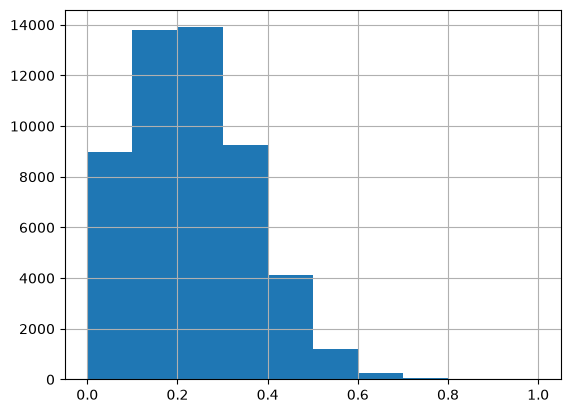

In [10]:
fd_df['transformed npp'].hist()

In [11]:
correlation = fd_df['transformed npp'].corr(fd_df['mean npp'])
print(f"Correlation between transformed npp and mean npp: {correlation:.3f}")

Correlation between transformed npp and mean npp: 0.453


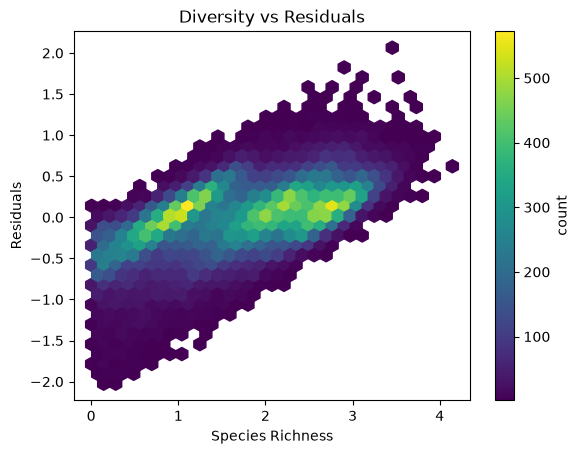

In [17]:
hb = plt.hexbin( fd_df['Raos_Q'],fd_df['residuals'], gridsize=30, cmap='viridis', mincnt=1)
plt.colorbar(hb, label='count')
plt.xlabel('Species Richness')
plt.ylabel('Residuals')
plt.title('Diversity vs Residuals')
plt.show()

In [16]:
X=fd_df.drop(columns=['transformed npp', 'mean npp', 'WSCI', 'Functional_Richness', 'PID', 'lat', 'lon', 'biome','treecover2000'])
X=X.drop(diversity_vars, axis=1)


scaler= StandardScaler()
scaler.fit_transform(X)

y = fd_df['Raos_Q'].values


model_c = xgb.XGBRegressor(**config["global"])
model_c.fit(X, y)

y_pred = model_c.predict(X)

residuals = y - y_pred
fd_df['residuals'] = residuals

In [19]:
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
y_pred = model_c.predict(X)
print("R2 score:", r2_score(y, y_pred))

R2 score: 0.8015298232584058


In [68]:
# X=fd_df.drop(columns=['transformed npp', 'mean npp', 'WSCI', 'Functional_Richness', 'PID', 'lat', 'lon', 'biome','treecover2000'])
# X=X.drop(diversity_vars, axis=1)

X=fd_df[['Shannon Diversity', 'mean npp']]

scaler= StandardScaler()
scaler.fit_transform(X)

y = fd_df['transformed npp'].values


model = xgb.XGBRegressor(**config["global"])
model.fit(X, y)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     48.1444
Link Function:                     IdentityLink Log Likelihood:                                 45123.0053
Number of Samples:                        51618 AIC:                                           -90147.7218
                                                AICc:                                          -90147.6263
                                                GCV:                                                0.0102
                                                Scale:                                               0.101
                                                Pseudo R-Squared:                                    0.411
Feature Function                  Lam

/tmp/ipykernel_2961699/1086030616.py:13: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


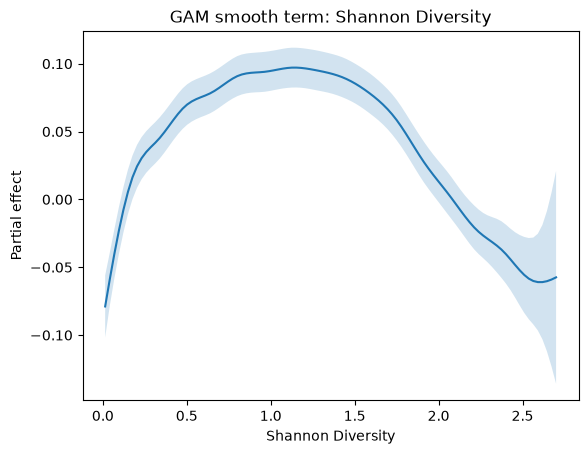

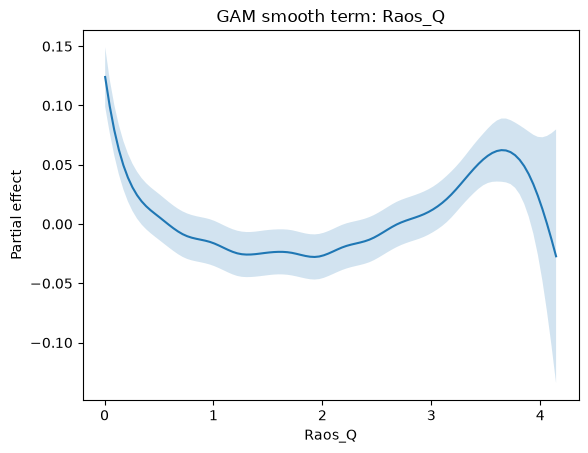

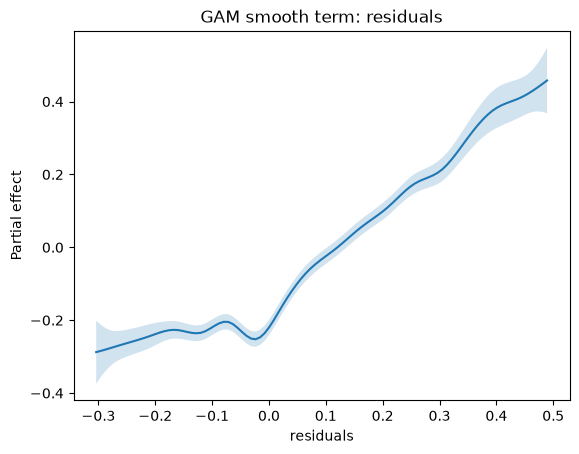

In [77]:
from pygam import LinearGAM, s
import matplotlib.pyplot as plt

# Pick ONE: either 'residuals' (environment-adjusted baseline) OR 'mean npp' (raw baseline) — not both
feature_names = ['Shannon Diversity', 'Raos_Q', 'residuals']  # dropped raw 'mean npp'

X = fd_df[feature_names].values
y = fd_df['transformed npp'].values

# One smooth term per column in X, matching the order of feature_names exactly
gam = LinearGAM(s(0) + s(1) + s(2)).fit(X, y)

print(gam.summary())

for i, name in enumerate(feature_names):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    plt.plot(XX[:, i], pdep)
    plt.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2)
    plt.xlabel(name)
    plt.ylabel('Partial effect')
    plt.title(f'GAM smooth term: {name}')
    plt.show()

In [69]:
y_pred = model.predict(X)
print("R2 score:", r2_score(y, y_pred))

R2 score: 0.3242588410966333


In [65]:
explainer = shap.Explainer(model, approximate=True)

shap_vals = explainer.shap_values(X, approximate=True)

shap_df = pd.DataFrame(shap_vals, columns=X.columns, index=X.index)


In [66]:
mean_importance = shap_df.abs().mean().sort_values(ascending=False)

In [67]:
print(mean_importance)

mean npp             0.053262
Shannon Diversity    0.021192
dtype: float32


In [25]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = model.predict(X)
print("R2 score:", r2_score(y, y_pred))

R2 score: 0.39377965006879734


In [15]:
diversity_vars = ["Species Richness", "Shannon Diversity", "Raos_Q", "Simpson's Index", "Functional_Evenness"]


In [ ]:

# climate= ["Annual Temp", "Annual Precipitation","CGIAR_Aridity_Index", "CHELSA_exBIO_GrowingSeasonLength",
#            'PET sd',  "Precipitation Seasonality", 'mean npp']

results = []
env_results = []

for d in diversity_vars:

    diversity_vars1=[v for v in diversity_vars if v != d]
    print(diversity_vars1)
    X=fd_df.drop(columns=['transformed npp','WSCI', 'Functional_Richness' , 'PID', 'lat', 'lon', 'biome','treecover2000'])
    X= X.drop(columns=diversity_vars1) 


    retained_vars = X.columns.tolist()
    retained_vars = [v for v in retained_vars if v != d]

    y= fd_df['transformed npp'].values

    scaler= StandardScaler()
    scaler.fit_transform(X)

    X = pd.DataFrame(
        X,
        columns=scaler.feature_names_in_
    )

    model = xgb.XGBRegressor(**config["global"])
    model.fit(X, y)

    explainer = shap.Explainer(model, approximate=True)

    shap_vals = explainer.shap_values(X, approximate=True)

    shap_df = pd.DataFrame(shap_vals, columns=X.columns, index=X.index)

    df_d = pd.DataFrame({f"shap_{d}": shap_df[d].values})
    df_env=pd.DataFrame({f"shap_{v}": shap_df[v].values for v in retained_vars})
    
    results.append(df_d)
    env_results.append(df_env)

shap_per_variable = pd.concat(results, axis=1)
shap_per_variable.insert(0, "PID", fd_df["PID"].values)

['Shannon Diversity', 'Raos_Q', "Simpson's Index", 'Functional_Evenness']
['Species Richness', 'Raos_Q', "Simpson's Index", 'Functional_Evenness']
['Species Richness', 'Shannon Diversity', "Simpson's Index", 'Functional_Evenness']
['Species Richness', 'Shannon Diversity', 'Raos_Q', 'Functional_Evenness']
['Species Richness', 'Shannon Diversity', 'Raos_Q', "Simpson's Index"]


In [60]:
shap_per_environment = pd.concat(env_results, axis=1)
shap_per_environment.insert(0, "PID", fd_df["PID"].values)

In [61]:
# Identify which columns are duplicated
dupe_mask = shap_per_environment.columns.duplicated(keep=False)
dupe_names = set(shap_per_environment.columns[dupe_mask])

# Split into numeric vs non-numeric duplicated columns
numeric_dupes = [c for c in dupe_names if pd.api.types.is_numeric_dtype(shap_per_environment[c])]
# careful: df[c] on a duplicated name returns ALL matching columns as a DataFrame, not a Series

# Average numeric columns, keep first occurrence of non-numeric duplicated columns
numeric_df = shap_per_environment.select_dtypes(include='number')
non_numeric_df = shap_per_environment.select_dtypes(exclude='number')

# Average numeric duplicates
numeric_avg = numeric_df.T.groupby(level=0).mean().T

# For non-numeric duplicates, just keep the first occurrence of each
non_numeric_dedup = non_numeric_df.loc[:, ~non_numeric_df.columns.duplicated(keep='first')]

# Recombine
env_df = pd.concat([non_numeric_dedup, numeric_avg], axis=1)

all_shap_df=shap_per_variable.merge(env_df, on='PID', how='left')

In [ ]:
# result_df=pd.DataFrame({
#     'PID': fd_df['PID'],
#     'biome': fd_df['biome'],
#     'y_true': y,
#     'y_pred': y_pred,
#     'lon': fd_df['lon'],
#     'lat': fd_df['lat']
# })
# result_df['absolute_error'] = np.abs(result_df['y_true'] - result_df['y_pred'])

#### SHAP plots 


In [32]:


biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}


In [43]:
shap_df2 = pd.concat(
    [
        fd_df.loc[fd_df.index, ["PID", "lat", "lon" ]].reset_index(drop=True),
        all_shap_df.reset_index(drop=True)
    ],
    axis=1
)
shap_df2 = shap_df2.loc[:, ~shap_df2.columns.duplicated(keep='first')]

In [16]:
# plot_df = plot_df[
#     (plot_df['Species Richness'] > 14  )
#     & (plot_df['Raos_Q'] > -0.5)
# ]

In [44]:
X=fd_df.drop(columns=['transformed npp','WSCI', 'Functional_Richness' , 'PID', 'lat', 'lon', 'biome','treecover2000'])


In [45]:
all_vars=all_shap_df.columns.tolist()
all_vars = [v for v in all_vars if v != 'PID']
all_vars = [ s.removeprefix('shap_') for s in all_vars ]

findfont: Failed to find font weight medium, now using 400.


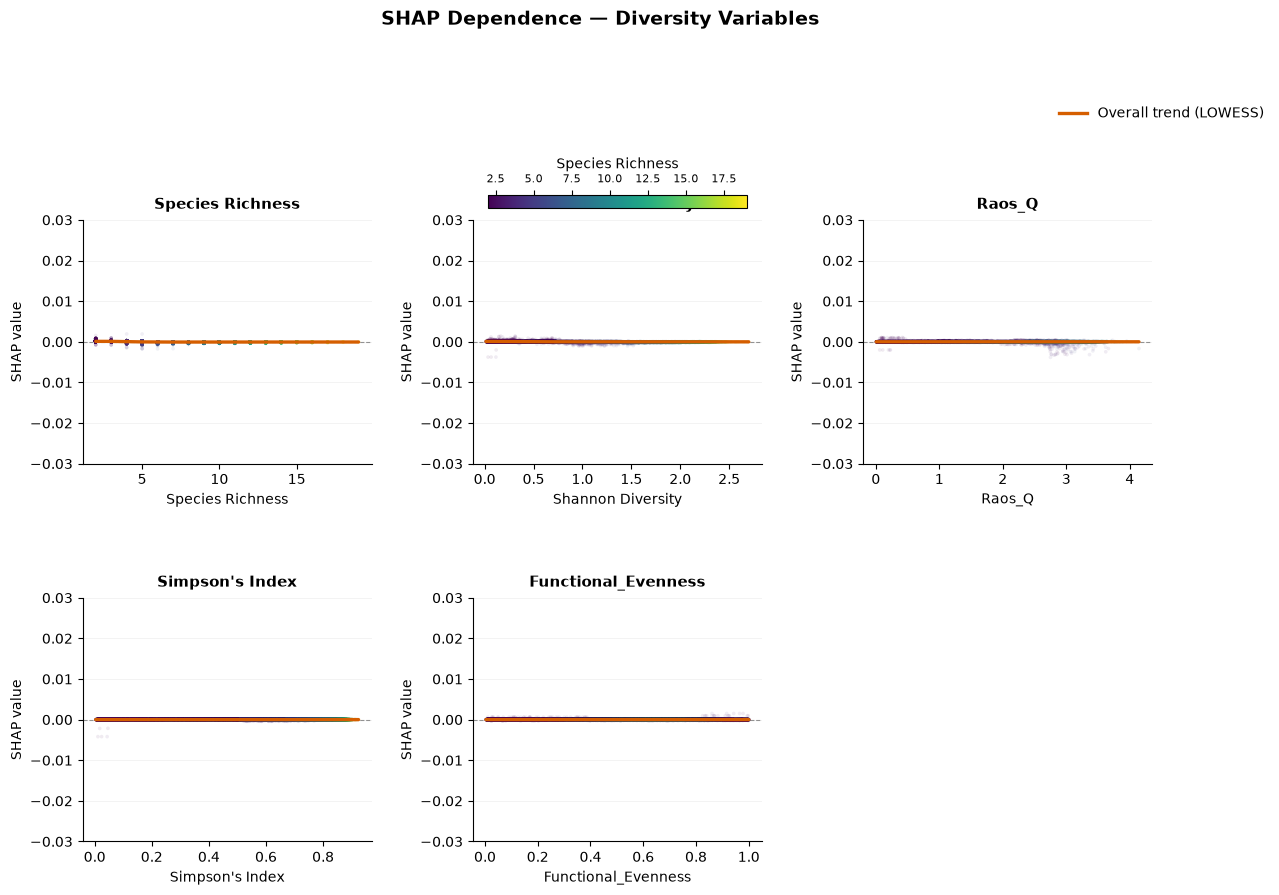

In [ ]:

# --- Build the merged dataframe: raw feature values + shap values + elevation ---
# X has the raw feature values (e.g. Raos_Q, Shannon Diversity, ...)
# all_shap_df has the matching shap_<feature> columns
# fd_df has elevation (and PID/lat/lon, as in your shap_df2 construction)

plot_df = pd.concat(
    [
        X.reset_index(drop=True),
        all_shap_df.reset_index(drop=True),
        fd_df.loc[X.index, ["Species Richness"]].reset_index(drop=True),  # adjust column name if different
    ],
    axis=1
)

plot_df = plot_df.loc[:, ~plot_df.columns.duplicated()]

# plot_df=plot_df[
#     (plot_df['Shannon Diversity'] > 1.8)
# ]


# --- Plot ---
fig = plot_shap_by_continuous(
    df=plot_df,
    features=diversity_vars,
    color_var="Species Richness",  # adjust column name if different
    color_var_label="Species Richness",
    cmap="viridis",
    n_cols=3,
    title="SHAP Dependence — Diversity Variables",
)

In [63]:
# shap_per_variable has columns: PID, shap_<var1>, shap_<var2>, ...
all_shap_df = all_shap_df.merge(fd_df[['PID', 'biome', 'WSCI']], on='PID', how='left')

sub_shap_df = all_shap_df[all_shap_df['biome'] == 'Temperate conifer forests'].copy()


shap_cols = [c for c in sub_shap_df.columns if c.startswith('shap_')]

shap_importance = pd.DataFrame({
    'feature': [c.replace('shap_', '') for c in shap_cols],
    'mean_abs_shap': [sub_shap_df[c].abs().mean() for c in shap_cols]
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance)

                             feature  mean_abs_shap
0                   Species Richness            0.0
1                  Shannon Diversity            0.0
2                             Raos_Q            0.0
3                    Simpson's Index            0.0
4                Functional_Evenness            0.0
5               Annual Precipitation            0.0
6                        Annual Temp            0.0
7            Burnt Areas Probability            0.0
8                CGIAR_Aridity_Index            0.0
9   CHELSA_exBIO_GrowingSeasonLength            0.0
10                  Depth to Bedrock            0.0
11          EarthEnvTopoMed_Eastness            0.0
12                         Elevation            0.0
13                        Land Cover            0.0
14                         Northness            0.0
15                            PET sd            0.0
16         Precipitation Seasonality            0.0
17                      SG_CEC_015cm            0.0
18          

In [ ]:
all_shap_df.to_csv("results/shap_values_per_variable.csv", index=False)

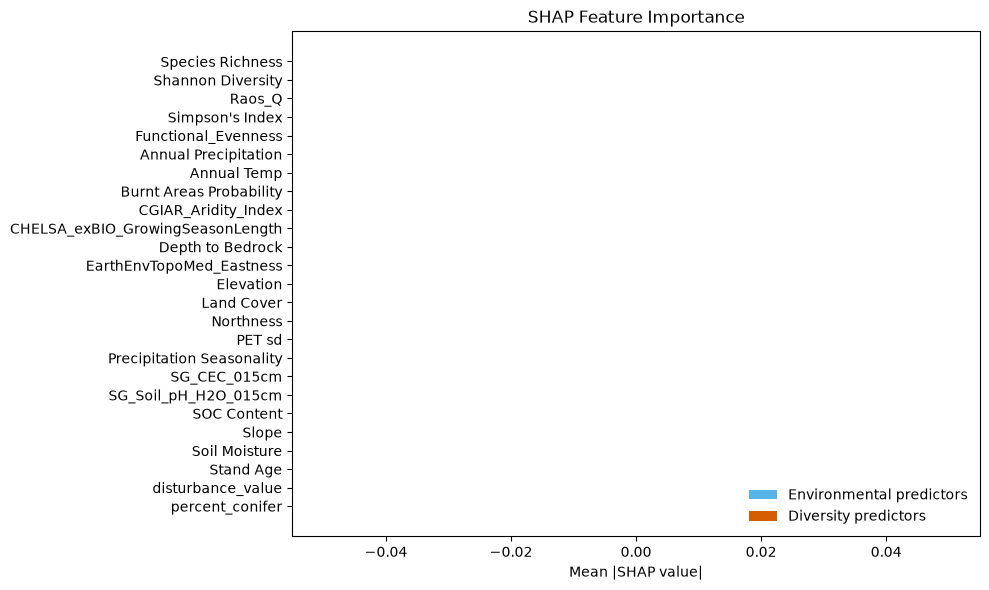

In [62]:
import matplotlib.pyplot as plt

diversity_vars = ["Species Richness", "Shannon Diversity", "Raos_Q", "Simpson's Index", "Functional_Evenness"]

colors = ['#D55E00' if f in diversity_vars else '#56B4E9' for f in shap_importance['feature']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shap_importance['feature'], shap_importance['mean_abs_shap'], color=colors)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance')
ax.invert_yaxis()  # highest value on top

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#56B4E9', label='Environmental predictors'),
    Patch(facecolor='#D55E00', label='Diversity predictors'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

findfont: Failed to find font weight medium, now using 400.


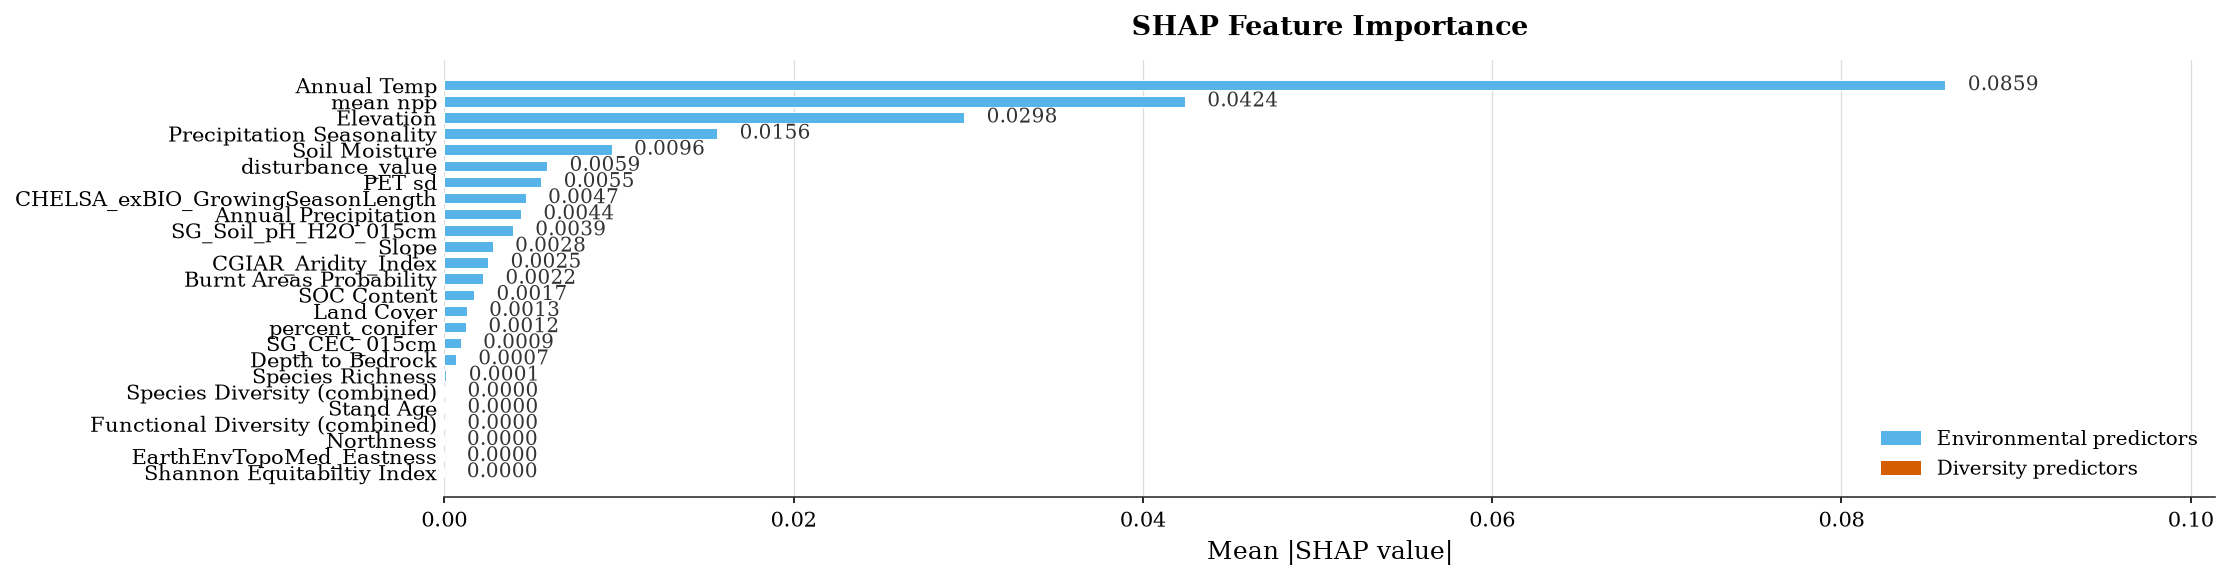

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# --- Publication-style rcParams ---
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'svg.fonttype': 'none',
})

# --- Define groups to combine ---
diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
species_richness_var = 'Species_Richness'  # <-- adjust to match your actual column name

# Sum SHAP importance within each group
functional_sum = shap_importance.loc[
    shap_importance['feature'].isin(diversity_vars_f), 'mean_abs_shap'
].sum()

species_sum = shap_importance.loc[
    shap_importance['feature'].isin(diversity_vars_s), 'mean_abs_shap'
].sum()

# Remove grouped vars only — species richness stays as its own row
all_diversity_vars = set(diversity_vars_f) | set(diversity_vars_s)
shap_importance_combined = shap_importance[
    ~shap_importance['feature'].isin(all_diversity_vars)
].copy()

# Add the two combined rows
summary_rows = pd.DataFrame({
    'feature': ['Functional Diversity (combined)', 'Species Diversity (combined)'],
    'mean_abs_shap': [functional_sum, species_sum]
})

shap_importance_combined = pd.concat(
    [shap_importance_combined, summary_rows], ignore_index=True
).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# --- Plot ---
n_bars = len(shap_importance_combined)
fig, ax = plt.subplots(figsize=(15, 4))

# Colorblind-safe palette (Okabe-Ito)
color_main = '#56B4E9'       # light blue — environmental predictors
color_diversity = '#D55E00'  # vermillion — combined diversity predictors
color_richness = '#D55E00'  # bluish green — species richness (own diversity metric)

def get_color(f):
    if f == species_richness_var:
        return color_richness
    elif f in summary_rows['feature'].values:
        return color_diversity
    else:
        return color_main

colors = [get_color(f) for f in shap_importance_combined['feature']]

bars = ax.barh(
    shap_importance_combined['feature'],
    shap_importance_combined['mean_abs_shap'],
    color=colors,
    height=0.65,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|', fontweight='medium')
ax.set_title('SHAP Feature Importance', fontweight='bold', pad=12)

# Clean spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=3)

# Subtle gridlines behind bars
ax.grid(axis='x', color='#dddddd', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# Value labels
max_val = shap_importance_combined['mean_abs_shap'].max()
for bar, value in zip(bars, shap_importance_combined['mean_abs_shap']):
    ax.text(
        bar.get_width() + max_val * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        va='center', ha='left',
        fontsize=9.5, color='#333333'
    )

ax.set_xlim(0, max_val * 1.18)

# Legend
legend_elements = [
    Patch(facecolor=color_main, label='Environmental predictors'),
    Patch(facecolor=color_diversity, label='Diversity predictors '),
]
ax.legend(
    handles=legend_elements, loc='lower right',
    frameon=False, fontsize=9.5
)

plt.tight_layout()

plt.show()


In [ ]:
import xgboost as xgb

booster = model.get_booster()  # if using XGBRegressor/XGBClassifier
tree_df = booster.trees_to_dataframe()

# Sum gain per tree to see which trees contributed the most
tree_gain = tree_df.groupby('Tree')['Gain'].sum().sort_values(ascending=False)
print(tree_gain.head(10))

Tree
0    10876.348615
1    10640.981330
2    10479.620004
3    10266.485883
4    10084.293770
5     9858.285426
6     9670.486397
7     9467.488279
8     9324.772551
9     9141.672874
Name: Gain, dtype: float64


In [ ]:
tree_df = booster.trees_to_dataframe()

# Find trees where Functional Diversity or Species Diversity actually appear as a split
diversity_trees = tree_df[tree_df['Feature'].isin(
    ['Raos_Q', 'Functional_Evenness', "Simpson's Index", 'Shannon Diversity']
)]

print(diversity_trees[['Tree', 'Feature', 'Split', 'Gain']].sort_values('Gain', ascending=False).head(10))

       Tree              Feature     Split      Gain
23414   186  Functional_Evenness  0.028168  1.594777
91278   816  Functional_Evenness  0.847042  1.378199
27873   222  Functional_Evenness  0.750591  1.248886
27644   220  Functional_Evenness  0.184162  1.246604
41670   335  Functional_Evenness  0.234456  1.229383
58976   486  Functional_Evenness  0.818506  1.169235
16795   133  Functional_Evenness  0.191919  1.157447
55753   457  Functional_Evenness  0.639888  1.150247
14266   113  Functional_Evenness  0.364416  1.125425
49869   405  Functional_Evenness  0.505728  1.093266


In [ ]:


booster = model.get_booster()

graph = xgb.to_graphviz(
    booster,
    tree_idx=75,                 # correct parameter name
    rankdir='LR',                # left-to-right layout, easier to read than top-down for wide trees
    size="20,12"                 # width,height in inches -- bump this up for deep trees
)

# Save as high-res PNG or vector PDF/SVG
# or for a crisp vector version you can zoom into infinitely:
graph.render('tree', format='svg', cleanup=True)   # tree_0.svg

'tree.svg'

In [ ]:
shap_df2.to_csv('data/final/global_shap_values.csv', index=False)

In [ ]:
# --- Publication-style rcParams ---
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'svg.fonttype': 'none',
})

# --- Build a dataframe from feature_importances_ ---
feature_names = X.columns.tolist()
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
})

# --- Combine diversity variable groups ---
diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
species_richness_var = 'Species Richness'  # <-- adjust to your actual column name

functional_sum = feature_importance.loc[
    feature_importance['feature'].isin(diversity_vars_f), 'importance'
].sum()
species_sum = feature_importance.loc[
    feature_importance['feature'].isin(diversity_vars_s), 'importance'
].sum()

# Remove the grouped variables (species richness stays as its own row)
all_diversity_vars = set(diversity_vars_f) | set(diversity_vars_s)
feature_importance_combined = feature_importance[
    ~feature_importance['feature'].isin(all_diversity_vars)
].copy()

summary_rows = pd.DataFrame({
    'feature': ['Functional Diversity', 'Species Diversity'],
    'importance': [functional_sum, species_sum]
})

feature_importance_combined = pd.concat(
    [feature_importance_combined, summary_rows], ignore_index=True
).sort_values('importance', ascending=False).reset_index(drop=True)

# --- Plot ---
n_bars = len(feature_importance_combined)
fig, ax = plt.subplots(figsize=(15, 4))

# Colorblind-safe palette (Okabe-Ito)
color_main = '#56B4E9'       # light blue — environmental predictors
color_diversity = '#D55E00'  # vermillion — combined diversity predictors
color_richness = '#D55E00'    # bluish green — species richness

def get_color(f):
    if f == species_richness_var:
        return color_richness
    elif f in summary_rows['feature'].values:
        return color_diversity
    else:
        return color_main

colors = [get_color(f) for f in feature_importance_combined['feature']]

bars = ax.barh(
    feature_importance_combined['feature'],
    feature_importance_combined['importance'],
    color=colors,
    height=0.65,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

ax.invert_yaxis()
ax.set_xlabel('Gini Importance', fontweight=400)
ax.set_title('Gini Feature Importance', fontweight='bold', pad=12)

# Clean spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=3)

# Subtle gridlines behind bars
ax.grid(axis='x', color='#dddddd', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# Value labels
max_val = feature_importance_combined['importance'].max()
for bar, value in zip(bars, feature_importance_combined['importance']):
    ax.text(
        bar.get_width() + max_val * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center', ha='left',
        fontsize=9.5, color='#333333'
    )

ax.set_xlim(0, max_val * 1.18)

# Legend for highlighted bars
legend_elements = [
    Patch(facecolor=color_main, label='Environmental predictors'),
    Patch(facecolor=color_diversity, label='Diversity predictors ')]
ax.legend(
    handles=legend_elements, loc='lower right',
    frameon=False, fontsize=9.5
)

plt.tight_layout()

plt.show()


# --- Publication-style rcParams ---
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'svg.fonttype': 'none',
})

# --- Run permutation importance on held-out data ---
result = permutation_importance(
    model,
    X, y,     # use held-out test data, not X/y used for training
    n_repeats=30,
    random_state=42,
    scoring='r2',        # swap for 'accuracy'/'roc_auc' etc. if classification
    n_jobs=-1
)

# --- Build a dataframe from permutation importance results ---
feature_names = X.columns.tolist()
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean,
    'importance_std': result.importances_std
})

# --- Define groups to combine ---
diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
species_richness_var = 'Species_Richness'  # <-- adjust to match your actual column name

# Sum importance within each group (variances add under independence assumption)
functional_sum = feature_importance.loc[
    feature_importance['feature'].isin(diversity_vars_f), 'importance'
].sum()
functional_std = np.sqrt((feature_importance.loc[
    feature_importance['feature'].isin(diversity_vars_f), 'importance_std'
] ** 2).sum())

species_sum = feature_importance.loc[
    feature_importance['feature'].isin(diversity_vars_s), 'importance'
].sum()
species_std = np.sqrt((feature_importance.loc[
    feature_importance['feature'].isin(diversity_vars_s), 'importance_std'
] ** 2).sum())

# Remove grouped vars only — species richness stays as its own row
all_diversity_vars = set(diversity_vars_f) | set(diversity_vars_s)
feature_importance_combined = feature_importance[
    ~feature_importance['feature'].isin(all_diversity_vars)
].copy()

# Add the two combined rows
summary_rows = pd.DataFrame({
    'feature': ['Functional Diversity (combined)', 'Species Diversity (combined)'],
    'importance': [functional_sum, species_sum],
    'importance_std': [functional_std, species_std]
})

feature_importance_combined = pd.concat(
    [feature_importance_combined, summary_rows], ignore_index=True
).sort_values('importance', ascending=False).reset_index(drop=True)

# --- Plot ---
n_bars = len(feature_importance_combined)
fig, ax = plt.subplots(figsize=(15, 4))

# Colorblind-safe palette (Okabe-Ito)
color_main = '#56B4E9'       # light blue — environmental predictors
color_diversity = '#D55E00'  # vermillion — combined diversity predictors
color_richness = '#D55E00'  # bluish green — species richness (own diversity metric)

def get_color(f):
    if f == species_richness_var:
        return color_richness
    elif f in summary_rows['feature'].values:
        return color_diversity
    else:
        return color_main

colors = [get_color(f) for f in feature_importance_combined['feature']]

bars = ax.barh(
    feature_importance_combined['feature'],
    feature_importance_combined['importance'],
    xerr=feature_importance_combined['importance_std'],
    color=colors,
    height=0.65,
    edgecolor='white',
    linewidth=0.5,
    error_kw={'ecolor': '#333333', 'elinewidth': 1, 'capsize': 3, 'capthick': 1},
    zorder=3
)

ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (mean decrease in R²)', fontweight='medium')
ax.set_title('Permutation Feature Importance', fontweight='bold', pad=12)

# Clean spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=3)

# Subtle gridlines behind bars
ax.grid(axis='x', color='#dddddd', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# Value labels — offset past the error bar, not just the bar end
max_val = feature_importance_combined['importance'].max()
for bar, value, err in zip(
    bars, feature_importance_combined['importance'],
    feature_importance_combined['importance_std']
):
    ax.text(
        bar.get_width() + err + max_val * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        va='center', ha='left',
        fontsize=9.5, color='#333333'
    )

max_err = feature_importance_combined['importance_std'].max()
ax.set_xlim(0, max_val + max_err + max_val * 0.2)

# Legend
legend_elements = [
    Patch(facecolor=color_main, label='Environmental predictors'),
    Patch(facecolor=color_diversity, label='Diversity predictors (combined)'),
]
ax.legend(
    handles=legend_elements, loc='lower right',
    frameon=False, fontsize=9.5
)

plt.tight_layout()

plt.show()

ValueError: All arrays must be of the same length

In [ ]:
# Make this compatible with global model not just local

eco=pd.read_csv('data/lookup/PID_with_ecoregion.csv')
biome_df=fd_df[['PID', 'biome', 'transformed npp', 'lon', 'lat', 'WSCI']]

subset_shap=shap_df2[[ 'PID','lon', 'lat','shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness', 'shap_Shannon Diversity', 'shap_Simpson\'s Index', 'shap_Species Richness']]

In [ ]:
# Identify the feature columns (everything except PID)
feature_cols = [c for c in subset_shap.columns if c not in['PID', 'lon', 'lat']]

# Find the column name with the largest SHAP value for each row
top_feature_df = pd.DataFrame({
    'PID': subset_shap['PID'],
    'top_feature': subset_shap[feature_cols].idxmax(axis=1),
    'lon': subset_shap['lon'],
    'lat': subset_shap['lat']
})



In [ ]:
subset_shap2=subset_shap[['PID']]

subset_shap2["shap_Functional_Diversity"] = (
    subset_shap["shap_Functional_Evenness"] +
    subset_shap["shap_Raos_Q"]
)

subset_shap2["shap_Species_Diversity"] = (
    subset_shap["shap_Simpson's Index"] +
    subset_shap["shap_Shannon Diversity"]
)

In [ ]:
eco_df = pd.merge(subset_shap2, eco, on='PID', how='left')
eco = eco.merge(ecoregions, on='ECO_NAME', how='left')

biome_df = biome_df.merge(eco, on='PID', how='left')

shap_cols = [col for col in eco_df.columns if col.startswith("shap_")]

# Mean SHAP values per ecoregion
eco_shap_mean = eco_df.groupby("ECO_NAME")[shap_cols].mean()
eco_shap_mean["dominant_feature"] = eco_shap_mean.idxmax(axis=1)

# Count of plots (PIDs) per ecoregion
plot_counts = eco_df.groupby("ECO_NAME")["PID"].nunique()
eco_shap_mean["plot_count"] = plot_counts

# Filter to ecoregions with more than 10 plots
eco_shap_mean = eco_shap_mean[eco_shap_mean["plot_count"] > 100]

eco_df = eco_shap_mean.merge(ecoregions, left_index=True, right_on="ECO_NAME", how="left")

/home/qli/Projects/env1/lib/python3.12/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


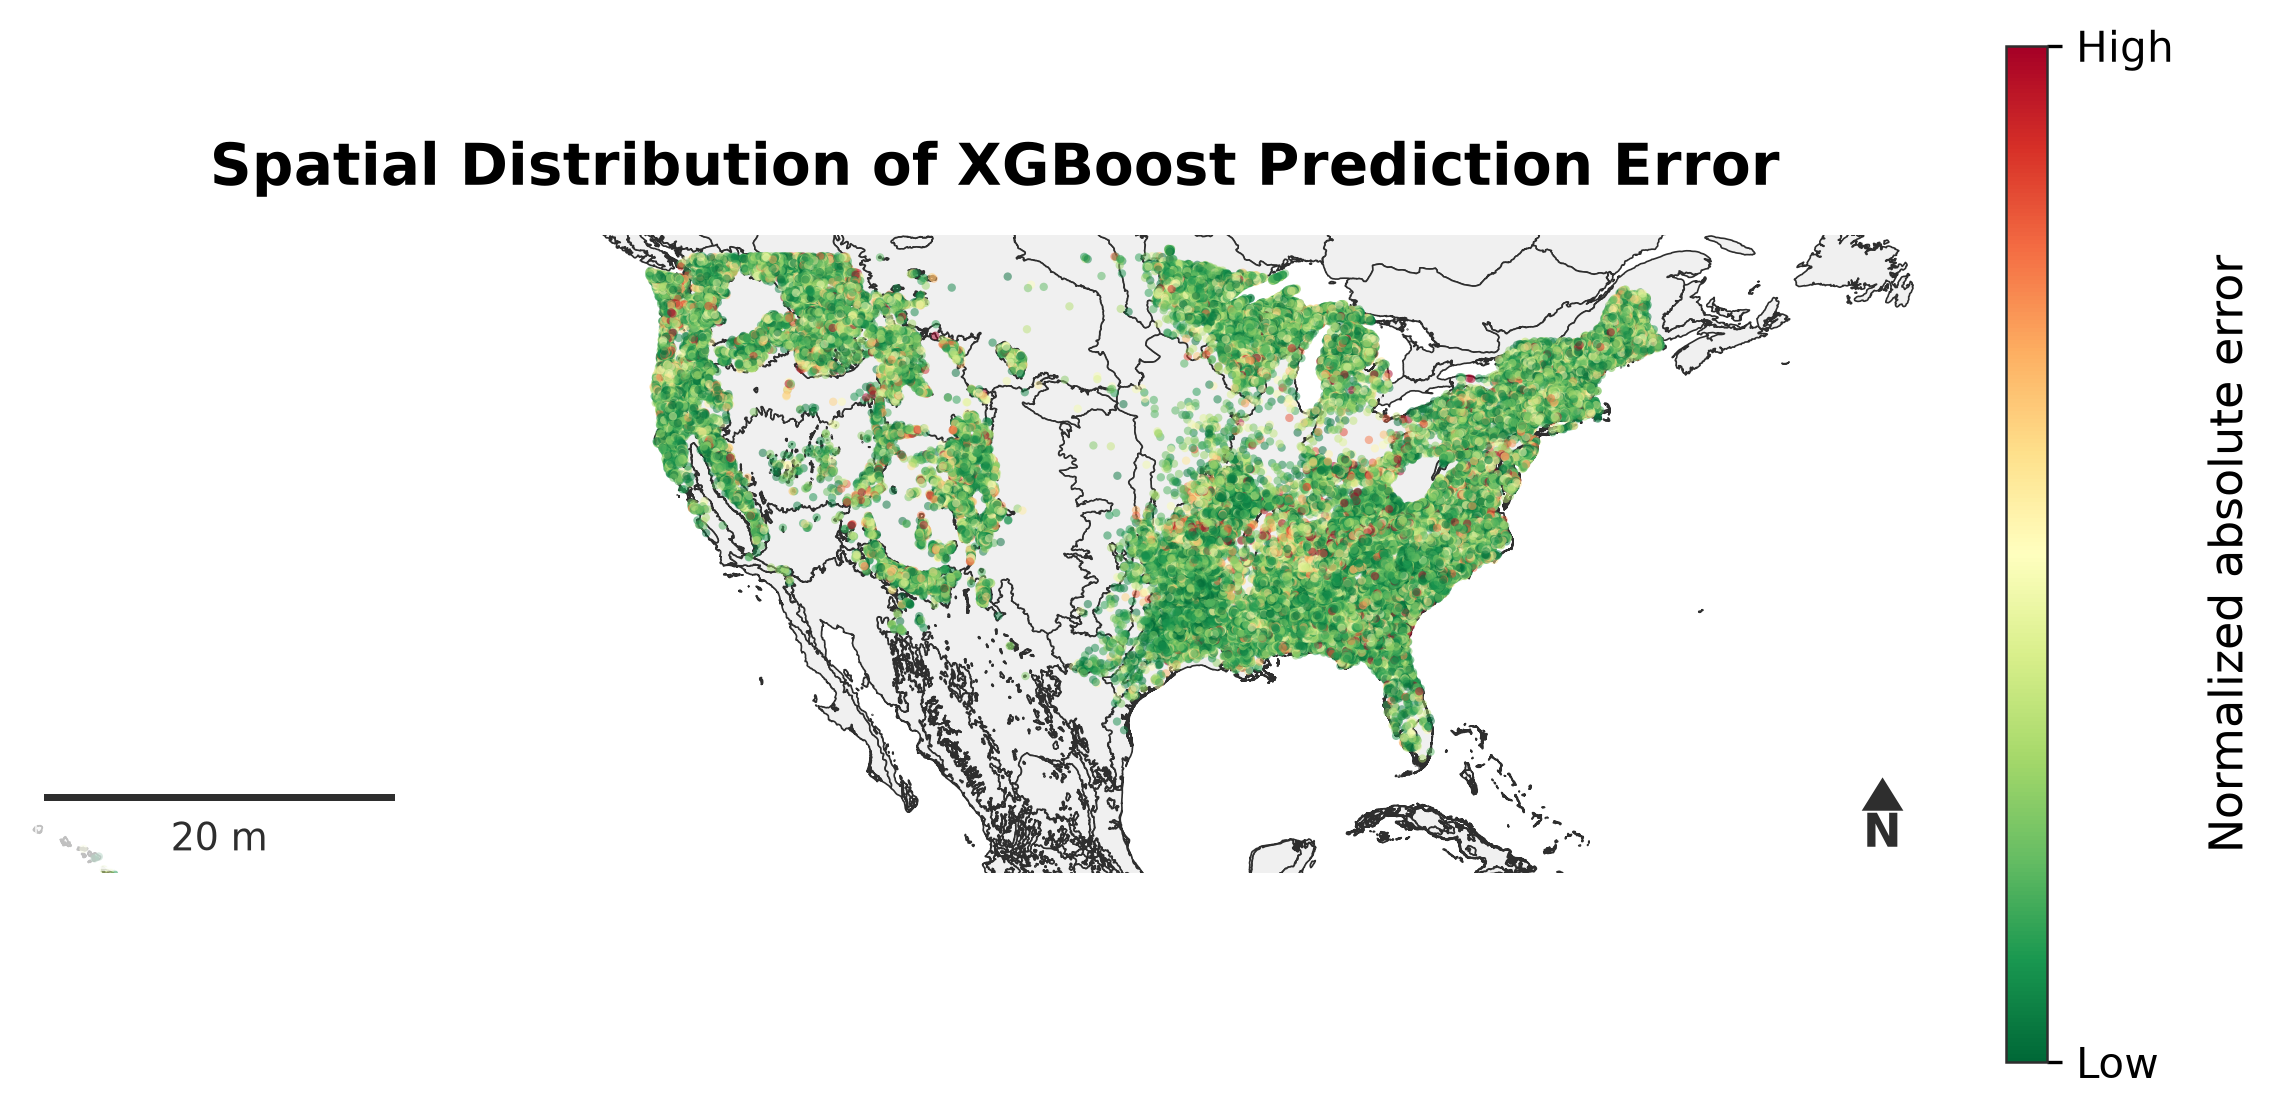

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib_scalebar.scalebar import ScaleBar  # pip install matplotlib-scalebar
import numpy as np

# ---------------------------------------------------------
# Global plotting style (consistent, publication-safe fonts)
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#2E2E2E",
    "svg.fonttype": "none",   # keeps text editable if exported as SVG
})

# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------
result_df["error_norm"] = (
    (result_df["absolute_error"] - result_df["absolute_error"].min()) /
    (result_df["absolute_error"].max() - result_df["absolute_error"].min())
)

result_gdf = gpd.GeoDataFrame(
    result_df,
    geometry=gpd.points_from_xy(result_df.lon, result_df.lat),
    crs="EPSG:4326"
)

ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")
result_gdf = result_gdf.to_crs(ecoregions.crs)

vmin = result_gdf["error_norm"].quantile(0.01)
vmax = result_gdf["error_norm"].quantile(0.99)

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

ecoregions.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#2E2E2E",
    linewidth=0.4,
    zorder=1
)

pts = result_gdf.plot(
    ax=ax,
    column="error_norm",
    cmap="RdYlGn_r",
    markersize=4,          # 0.5 is invisible in print — bumped up
    vmin=vmin,
    vmax=vmax,
    alpha=0.5,
    linewidth=0,
    zorder=2,
    legend=False           # build the colorbar manually for full control
)

# ---------------------------------------------------------
# Colorbar — manual, so labels/ticks/position are exact
# ---------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02, aspect=25)
cbar.set_label("Normalized absolute error", fontsize=11, labelpad=8)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["Low", "High"])
cbar.outline.set_edgecolor("#2E2E2E")
cbar.outline.set_linewidth(0.6)

# ---------------------------------------------------------
# North arrow
# ---------------------------------------------------------
ax.annotate(
    "N", xy=(0.96, 0.15), xytext=(0.96, 0.06),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="#2E2E2E", edgecolor="none", width=3, headwidth=10, headlength=8),
    ha="center", va="center", fontsize=11, fontweight="bold", color="#2E2E2E"
)

# ---------------------------------------------------------
# Scale bar (uses the CRS's linear unit automatically)
# ---------------------------------------------------------
ax.add_artist(ScaleBar(
    dx=1, units="m", location="lower left",
    box_alpha=0.7, color="#2E2E2E", font_properties={"size": 9}
))

# ---------------------------------------------------------
# Titling, extent, frame
# ---------------------------------------------------------
ax.set_title("Spatial Distribution of XGBoost Prediction Error", pad=12)
ax.set_axis_off()

ax.set_xlim(-160, -50)
ax.set_ylim(20, 50)

# Thin frame around the whole map panel (common in journal figures)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#2E2E2E")
    spine.set_linewidth(0.8)

plt.show()